# Plane-parallel slab example showing the usage of:
# High-level `LineRt` with callable fields

This notebook mirrors `docs/examples/plane_parallel_hl.py`
but in interactive form.  A uniform slab of CO (J=1->0) is
illuminated from one face; photons scatter in the line and
are continuously absorbed by dust.  The field arrays
(`n_species`, `temperature`, `vel`) are provided as
**callables** so they can be spatially varying.

Run directory is auto-created under `/tmp/line_rt/`.

In [1]:
############################################################# Impoort thingsimport sys, os;_PROJECT = os.path.expanduser( \    '~/Seafile/seafile_sync/code/line_rt_pipeline' );if _PROJECT not in sys.path:    sys.path.insert( 0, _PROJECT );%matplotlib inlineimport matplotlib;import matplotlib.pyplot as plt;from numpy import full, zeros, linspace, asarray, \                  max as np_max, float64;from core.line_rt            import LineRt;from molecular.transition_info import TransitionInfo;AU   = 1.49598e13;   # cmLsun = 3.828e33;     # erg/s############################################################

In [31]:
############################################################# Configure `LineRt` (Using the species-based info group)############################### Pass the callables directly as `n_species`, `temperature`,# and `vel`.  `LineRt` calls them internally after building# the mesh.ti         = TransitionInfo( 'CO', 0 );tr         = ti.transition;sigma_co   = ti.species_data.cross_section( 0, b_sca );L_slab_cm  = 10.0 * AU;   # x_min=-5, x_max=5 -> L=10 AUn_species  = ( tau0_slab / L_slab_cm ) / sigma_co; # cm^-3rt = LineRt(    n_cell       = ( 64, 2, 2 ),    x_min        = ( -5, 0, 0 ), x_max = ( 5, 0.2, 0.2 ),    unit_l0      = AU, unit_t0 = 1.0,    transition_info = ti,    n_species       = n_total_callable,    temperature     = temperature_callable,    vel             = ( vx_callable, 0.0, 0.0 ),    ph_mode      = 2,  # R_IIA, const-mem (production mode)    n_step       = 200000,    n_scat       = 20000,    n_cycles     = 3,    n_emission_max = 5,    visualize    = False,);rt.set_boundary( 'fre fre per per per per' );# Slab source at x=-5 (left face), 0.8 Lsun at 2.6 mmrt.add_source(    type       = 'slab', x = -5.0, direction = '+x',    n_photon   = 20000,    flux       = 1e-7,    wavelength = 2.6e-1, # CO J=1->0 ~ 115 GHz -> 2.6 mm);print( 'Mesh: %s, sources: %d' %       ( rt._n_cell, len( rt._sources ) ) );############################################################

Mesh: (64, 2, 2), sources: 1


In [32]:
############################################################# Run the Monte Carlo simulations iteratively############################### The run directory is printed and everything (`.par`,# `.bin` files) goes under `/tmp/line_rt/rt_<timestamp>/`.results = rt.run(  );############################################################

=== Consistency check ===
  species  : CO (10 levels, 9 transitions)
  n_species: <callable n_total_callable> cm⁻³
  temperature: <function temperature_callable at 0x777251ac7e20> K
  Transition #0: J=1->0, E_u=3.8 K, E_l=0.0 K, g_u=3, g_l=1, A_ul=7.20e-08 s⁻¹, ν=115.271 GHz, λ=2600.8 µm
  σ₀ = (b_sca to be resolved from callable at runtime)
  b_sca    : (not provided)
  mfp_i_sca_0: (not provided)
  ── Using Group 1 (species-based) ──
  sources  : 1 source(s)
    [0] slab, 20000 photons, 1e-07 erg cm⁻² s⁻¹ (λ=0.26 cm)
=== All checks passed ===

[LineRt] Run directory: /tmp/line_rt/rt_20260802_122306
[iterate] Run directory: /tmp/line_rt/rt_20260802_122306
Wrote fields (fixed): /tmp/line_rt/rt_20260802_122306/fields_fixed.bin
Wrote fields (line): /tmp/line_rt/rt_20260802_122306/fields_cycle0.bin
Wrote photons: /tmp/line_rt/rt_20260802_122306/photons_cycle0.bin (20000 photons, 8 cols)
Wrote par file: /tmp/line_rt/rt_20260802_122306/cycle0.par


[cycle 0] Done in 1s, bin=cycle0_00000.bin
Wrote fields (line): /tmp/line_rt/rt_20260802_122306/fields_cycle1.bin
Wrote photons: /tmp/line_rt/rt_20260802_122306/photons_cycle1.bin (21280 photons, 9 cols)
Wrote par file: /tmp/line_rt/rt_20260802_122306/cycle1.par


[cycle 1] Done in 1s, bin=cycle1_00000.bin
Wrote fields (line): /tmp/line_rt/rt_20260802_122306/fields_cycle2.bin
Wrote photons: /tmp/line_rt/rt_20260802_122306/photons_cycle2.bin (22560 photons, 9 cols)
Wrote par file: /tmp/line_rt/rt_20260802_122306/cycle2.par


[cycle 2] Done in 1s, bin=cycle2_00000.bin


In [33]:
############################################################# Print the run information##############################res_list = results[ 'results' ];mesh     = results[ 'mesh' ];nxc      = int( mesh[ 'n_cell' ][ 0 ] );x_cell   = linspace( -5, 5, nxc );for k, res in enumerate( res_list ):    flx   = res.get( 'flx' );    exc   = res.get\    ( 'exc_flux_flat', res.get( 'excitation_flux' ) );    n_esc = len( res.get( 'photons', {} ).get( 'vel', [] ) );    if flx is not None:        print\        ( '  Cycle %d: flx_max=%.2e  exc_max=%.2e  n_esc=%d'          % ( k, np_max( flx ), np_max( exc ), n_esc ) );    else:        print( '  Cycle %d: flx=N/A  exc=N/A  n_esc=%d'               % ( k, n_esc ) );############################################################

  Cycle 0: flx_max=5.01e+08  exc_max=2.52e+08  n_esc=20000
  Cycle 1: flx_max=5.06e+08  exc_max=2.53e+08  n_esc=21280
  Cycle 2: flx_max=5.02e+08  exc_max=2.53e+08  n_esc=22560


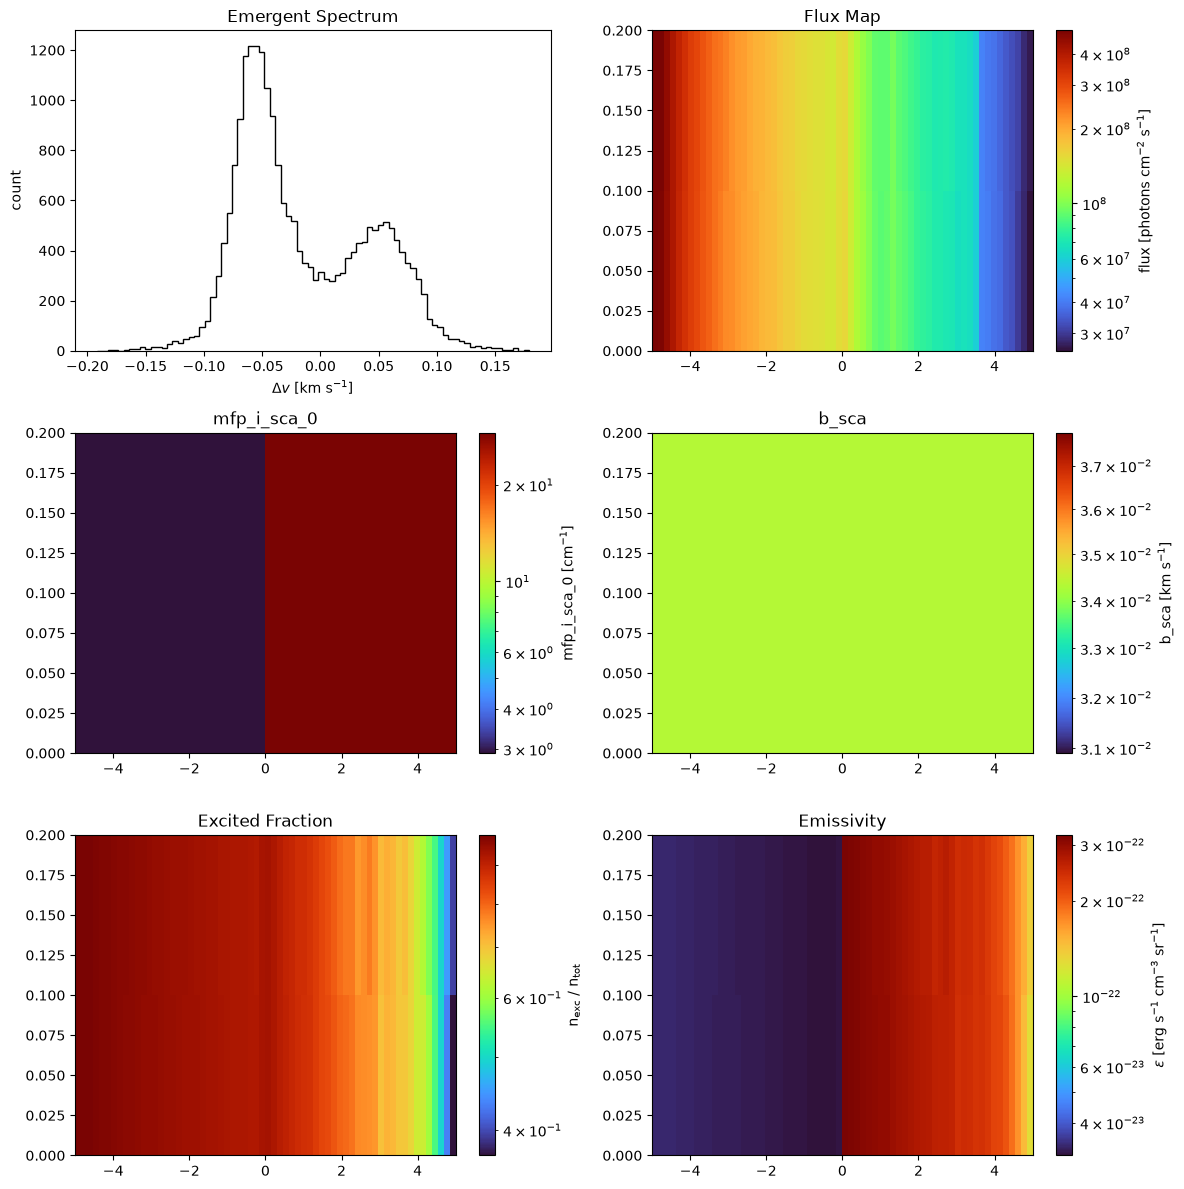

In [34]:
############################################################# Default multi-panel plot############################### `default_plot()` from `core.visualize` generates a# 2-column, N-row panel grid.  The default field list:# emergent spectrum (km/s histogram), flux map, mfp_i_sca_0,# b_sca, excited fraction, emissivity - all as logarithmic# colormaps (except the spectrum).  Missing fields leave a# blank panel with title.  Pass `dyn_range=True` to clip the# color scale to integer-dex bounds.##############################from core.visualize import default_plot;fig, axes = default_plot( results, dyn_range = False );############################################################

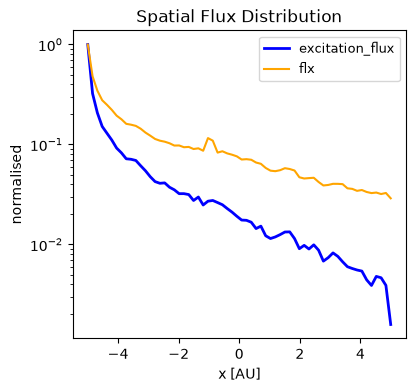

In [15]:
############################################################# Spatial distribution##############################exc_flat = results.get( 'exc_flux_flat' );flx_flat = results.get( 'flx' );fig, ax = plt.subplots( figsize = ( 4.3, 4 ) );if exc_flat is not None and flx_flat is not None:    # 3D arrays (nz, ny, nx) -> take the x-profile at z=y=0    exc_x = exc_flat[ 0, 0, : ];    flx_x = flx_flat[ 0, 0, : ];    ax.plot( x_cell, exc_x / ( exc_x.max( ) or 1 ), 'b-',             lw = 2, label = 'excitation_flux' );    ax.plot( x_cell, flx_x / ( flx_x.max( ) or 1 ),             color = 'orange',  lw = 1.5, label = 'flx' );    ax.set( xlabel = 'x [AU]', ylabel = 'normalised' );    ax.set_yscale( 'log' );    ax.legend( fontsize = 9 );else:    ax.text( 0.5, 0.5, 'No flux data',             transform = ax.transAxes, ha = 'center' );ax.set_title( 'Spatial Flux Distribution' );plt.show( );############################################################

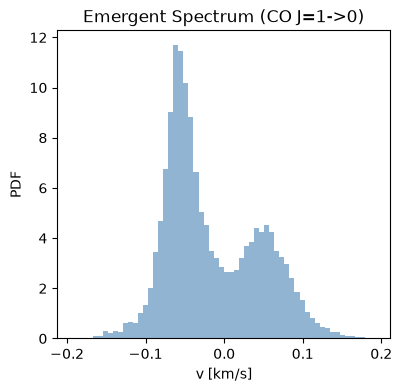

In [16]:
############################################################# Emergent spectra##############################spectrum = results.get( 'spectrum', {} );vel_data = asarray( spectrum.get( 'vel', [ ] ) );fig, ax = plt.subplots( figsize = ( 4.3, 4 ) );if len( vel_data ) > 0:    ax.hist( vel_data * 1e-5, bins = 60, density = True, \             alpha = 0.6, color = 'steelblue' );    ax.set( xlabel = 'v [km/s]', ylabel = 'PDF' );else:    ax.text( 0.5, 0.5, 'No escaped photons', \             transform = ax.transAxes, ha = 'center' );ax.set_title( 'Emergent Spectrum (CO J=1->0)' );plt.show( );############################################################

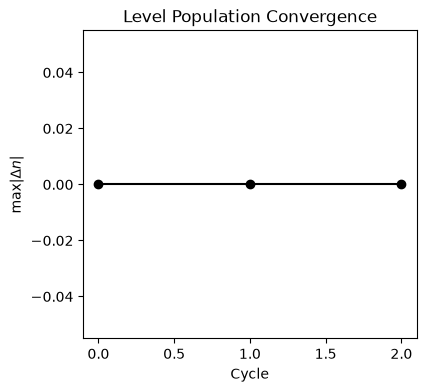

In [17]:
############################################################# Population convergencepop_hist = [ r[ 'populations' ] for r in res_list \             if 'populations' in r ];fig, ax = plt.subplots( figsize = ( 4.3, 4 ) );if len( pop_hist ) >= 2:    from core.visualize import plot_convergence;    plot_convergence( ax, pop_hist,                      list( range( len( pop_hist ) ) ) );else:    ax.text( 0.5, 0.5, 'No convergence data', \             transform = ax.transAxes, ha = 'center' );ax.set_title( 'Level Population Convergence' );plt.show( );############################################################

In [11]:
############################################################# Run directory structurerun_dir = results.get( 'run_dir' ) or rt._resolve_path( );print( 'Run directory: %s' % run_dir );for f in sorted( os.listdir( run_dir ) ):    sz = os.path.getsize( os.path.join( run_dir, f ) );    print( '  %-30s  %10d bytes' % ( f, sz ) );############################################################

Run directory: /tmp/line_rt/rt_20260802_111252
  cycle0.par                             832 bytes
  cycle0_00000.bin                    677698 bytes
  cycle1.par                             832 bytes
  cycle1_00000.bin                    718658 bytes
  cycle2.par                             832 bytes
  cycle2_00000.bin                    759618 bytes
  fields_cycle0.bin                     5181 bytes
  fields_cycle1.bin                     5181 bytes
  fields_cycle2.bin                     5181 bytes
  fields_fixed.bin                     10225 bytes
  photons_cycle0.bin                  640133 bytes
  photons_cycle1.bin                  766213 bytes
  photons_cycle2.bin                  812293 bytes
